In [18]:
# ============================================================================
# COMPLETE PREPROCESSING: CSV → level_2_data with all indicators
# ============================================================================

import pandas as pd
import numpy as np
import yfinance as yf

# --- Step 1: Load CSV ---
print("Loading CSV data...")
data = pd.read_csv('/kaggle/input/findata/act-adj-close-df (1).csv')
data['Date'] = pd.to_datetime(data['Date'])

# Get ticker list and date range
tickers = [col for col in data.columns if col != 'Date']
start_date = data['Date'].min()
end_date = data['Date'].max()

print(f"Tickers: {tickers}")
print(f"Date range: {start_date.date()} to {end_date.date()}")

# --- Step 2: Convert to long format ---
print("\nConverting to long format...")
data_long = data.melt(id_vars=['Date'], value_vars=tickers, var_name='Ticker', value_name='Close')

# --- Step 3: Download OHLV data from yfinance ---
print("\nDownloading OHLV data from yfinance...")
ohlv_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False, progress=True)

# Convert OHLV to long format
ohlv_long_list = []
for ticker in tickers:
    if len(tickers) > 1:
        ticker_df = ohlv_data.xs(ticker, level=1, axis=1).reset_index()
    else:
        ticker_df = ohlv_data.reset_index()
    ticker_df['Ticker'] = ticker
    ohlv_long_list.append(ticker_df[['Date', 'Ticker', 'Open', 'High', 'Low', 'Volume']])

ohlv_long = pd.concat(ohlv_long_list, ignore_index=True)

# --- Step 4: Create Level 0 data ---
print("\nCreating Level 0 data...")
level_0_data = pd.merge(
    data_long[['Date', 'Ticker', 'Close']],
    ohlv_long[['Date', 'Ticker', 'Open', 'High', 'Low', 'Volume']],
    on=['Date', 'Ticker'],
    how='left'
)

# Fill missing OHLV with Close price
level_0_data['Open'].fillna(level_0_data['Close'], inplace=True)
level_0_data['High'].fillna(level_0_data['Close'], inplace=True)
level_0_data['Low'].fillna(level_0_data['Close'], inplace=True)
level_0_data['Volume'].fillna(0, inplace=True)

# Clean up
level_0_data.dropna(subset=['Close'], inplace=True)
level_0_data['Volume'] = level_0_data['Volume'].astype(int)
level_0_data.sort_values(by=['Date', 'Ticker'], inplace=True)
level_0_data.reset_index(drop=True, inplace=True)

print("Level 0 data created.")
print(level_0_data.head())

# --- Step 5: Calculate Level 1 indicators ---
print("\nCalculating Level 1 technical indicators...")

def calculate_indicators(stock_df):
    """Calculate all technical indicators for a single stock."""
    stock_df = stock_df.sort_values(by='Date').copy()
    
    # Returns and volatility
    stock_df['Daily_Return'] = stock_df['Close'].pct_change() * 100
    stock_df['Rolling_Vol_20D'] = stock_df['Daily_Return'].rolling(window=20).std()
    stock_df['Momentum_10D'] = stock_df['Close'].diff(periods=10)
    
    # Moving averages
    stock_df['SMA_10'] = stock_df['Close'].rolling(window=10).mean()
    stock_df['SMA_20'] = stock_df['Close'].rolling(window=20).mean()
    stock_df['SMA_50'] = stock_df['Close'].rolling(window=50).mean()
    stock_df['EMA_200'] = stock_df['Close'].ewm(span=200, adjust=False).mean()
    
    # RSI
    delta = stock_df['Close'].diff(1)
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.ewm(com=13, min_periods=14).mean()
    avg_loss = loss.ewm(com=13, min_periods=14).mean()
    rs = avg_gain / avg_loss
    stock_df['RSI_14'] = 100 - (100 / (1 + rs))
    
    # MACD
    ema_12 = stock_df['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = stock_df['Close'].ewm(span=26, adjust=False).mean()
    stock_df['MACD'] = ema_12 - ema_26
    stock_df['MACD_Signal'] = stock_df['MACD'].ewm(span=9, adjust=False).mean()
    stock_df['MACD_Histogram'] = stock_df['MACD'] - stock_df['MACD_Signal']
    
    # Bollinger Bands
    sma_20 = stock_df['SMA_20']
    std_20 = stock_df['Close'].rolling(window=20).std()
    upper_band = sma_20 + (std_20 * 2)
    lower_band = sma_20 - (std_20 * 2)
    stock_df['BB_Percent'] = (stock_df['Close'] - lower_band) / (upper_band - lower_band)
    
    # OBV
    signed_volume = stock_df['Volume'] * np.sign(stock_df['Close'].diff().fillna(0))
    stock_df['OBV'] = signed_volume.cumsum()
    
    return stock_df

level_1_data = level_0_data.groupby('Ticker', group_keys=False).apply(calculate_indicators)
level_1_data.sort_values(by=['Date', 'Ticker'], inplace=True)
level_1_data.reset_index(drop=True, inplace=True)

print("Level 1 data created.")
print(level_1_data.head())

# --- Step 6: Add Level 2 market indicators ---
print("\nAdding Level 2 market indicators (S&P 500, VIX)...")

# Download S&P 500
sp500_data_raw = yf.download('^GSPC', start=start_date, end=end_date, 
                             auto_adjust=False, progress=False)
sp500_data = sp500_data_raw.reset_index()[['Date', 'Adj Close', 'Volume']]
sp500_data.columns = ['Date', 'S&P500_Close', 'S&P500_Volume']

# Download VIX
vix_data_raw = yf.download('^VIX', start=start_date, end=end_date, 
                           auto_adjust=False, progress=False)
vix_data = vix_data_raw.reset_index()[['Date', 'Adj Close']]
vix_data.columns = ['Date', 'VIX_Close']

# Combine market data
market_data = pd.merge(sp500_data, vix_data, on='Date', how='outer')

# Merge with main panel
level_2_data = pd.merge(level_1_data, market_data, on='Date', how='left')

# Forward fill market data for non-trading days
cols_to_fill = ['S&P500_Close', 'S&P500_Volume', 'VIX_Close']
level_2_data[cols_to_fill] = level_2_data[cols_to_fill].ffill().bfill()

# Final cleanup
level_2_data.sort_values(by=['Date', 'Ticker'], inplace=True)
level_2_data.reset_index(drop=True, inplace=True)

print("\n✅ Level 2 data created successfully!")
print(f"Shape: {level_2_data.shape}")
print(f"\nFirst few rows:")
print(level_2_data.head())
print(f"\nColumns:")
print(level_2_data.columns.tolist())
print(f"\nData info:")
print(level_2_data.info())

Loading CSV data...
Tickers: ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'BRK-A', 'NVDA', 'V', 'JPM', 'UNH', 'JNJ', 'BAC', 'WMT', 'PG', 'HD', 'MA', 'XOM', 'PFE', 'DIS', 'CVX', 'KO', 'AVGO', 'PEP', 'CSCO', 'WFC', 'COST', 'LLY', 'ADBE']
Date range: 2009-12-31 to 2021-12-31

Converting to long format...



[*********************100%***********************]  27 of 27 completed



Creating Level 0 data...
Level 0 data created.
        Date Ticker       Close       Open       High        Low     Volume
0 2009-12-31   AAPL    6.444381   7.611786   7.619643   7.520000  352410800
1 2009-12-31   ADBE   36.779999  37.169998  37.209999  36.700001    2900400
2 2009-12-31   AMZN  134.520004   6.854500   6.864000   6.726000   90460000
3 2009-12-31   AVGO   13.908897   1.761000   1.829000   1.761000    5558000
4 2009-12-31    BAC   12.931032  15.090000  15.240000  15.010000   94322600

Calculating Level 1 technical indicators...
Level 1 data created.
        Date Ticker       Close       Open       High        Low     Volume  \
0 2009-12-31   AAPL    6.444381   7.611786   7.619643   7.520000  352410800   
1 2009-12-31   ADBE   36.779999  37.169998  37.209999  36.700001    2900400   
2 2009-12-31   AMZN  134.520004   6.854500   6.864000   6.726000   90460000   
3 2009-12-31   AVGO   13.908897   1.761000   1.829000   1.761000    5558000   
4 2009-12-31    BAC   12.931032  1

In [19]:
level_2_data.columns

Index(['Date', 'Ticker', 'Close', 'Open', 'High', 'Low', 'Volume',
       'Daily_Return', 'Rolling_Vol_20D', 'Momentum_10D', 'SMA_10', 'SMA_20',
       'SMA_50', 'EMA_200', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Histogram',
       'BB_Percent', 'OBV', 'S&P500_Close', 'S&P500_Volume', 'VIX_Close'],
      dtype='object')

In [20]:
import pandas as pd
import numpy as np
import sys
from sklearn.preprocessing import StandardScaler # <-- Import the scaler

def prepare_univariate_datasets(data_df, lookback_window, test_size):
    """
    Transforms the long-format level_2_data into a dictionary of datasets,
    one for each ticker. It now removes all NaN rows AND scales the features.

    Args:
        data_df (pd.DataFrame): The 'level_2_data' DataFrame.
        lookback_window (int): The number of time steps to look back (e.g., 20).
        test_size (float): The percentage of data to use for testing (e.g., 0.2).

    Returns:
        dict: A dictionary where keys are tickers, and values are dicts
              containing scaled 'X_train', 'y_train', 'X_test', 'y_test',
              and the 'scaler' itself.
    """
    
    print("Preparing 27 separate univariate datasets (with scaling)...")
    
    all_datasets = {}
    tickers_list = data_df['Ticker'].unique()
    
    for ticker in tickers_list:
        print(f"  Processing data for {ticker}...")
        
        # 1. Isolate and Clean
        stock_df = data_df[data_df['Ticker'] == ticker].copy()
        stock_df.sort_values(by='Date', inplace=True)
        stock_df.dropna(inplace=True) 
        
        if len(stock_df) < (lookback_window + 50):
            print(f"    Skipping {ticker}: Not enough data after NaN removal.")
            continue

        # 2. Define Features and Target
        feature_cols = [col for col in stock_df.columns if col not in ['Date', 'Ticker']]
        target_col = 'Daily_Return'
        
        # 3. Create Sliding Windows
        X_stock = []
        y_stock = []
        
        for i in range(len(stock_df) - lookback_window):
            X_window = stock_df.iloc[i : i + lookback_window][feature_cols].values
            y_target = stock_df.iloc[i + lookback_window][target_col]
            X_stock.append(X_window)
            y_stock.append(y_target)

        X_stock = np.array(X_stock)
        y_stock = np.array(y_stock)

        # 4. Split into Train/Test (BEFORE scaling)
        split_idx = int(len(X_stock) * (1 - test_size))
        
        X_train = X_stock[:split_idx]
        y_train = y_stock[:split_idx]
        X_test = X_stock[split_idx:]
        y_test = y_stock[split_idx:]

        # ---
        # 5. (NEW STEP) SCALE THE DATA (X only)
        # ---
        
        # Get shapes for reshaping
        n_samples_train, n_timesteps, n_features = X_train.shape
        n_samples_test = X_test.shape[0]
        
        # We scale the 'y' (target) data ONLY if it's not a return (e.g., 'Close' price)
        # Since our target is 'Daily_Return' (a percentage), we leave it unscaled.
        
        # Initialize the scaler
        scaler = StandardScaler()
        
        # Reshape X_train from 3D to 2D (samples * timesteps, features)
        # This is required so the scaler can fit all features at once
        X_train_reshaped = X_train.reshape(n_samples_train * n_timesteps, n_features)
        
        # Fit the scaler ONLY on the training data
        scaler.fit(X_train_reshaped)
        
        # Transform (scale) the training data
        X_train_scaled_reshaped = scaler.transform(X_train_reshaped)
        
        # Reshape X_test from 3D to 2D
        X_test_reshaped = X_test.reshape(n_samples_test * n_timesteps, n_features)
        
        # Transform (scale) the test data using the *same scaler*
        X_test_scaled_reshaped = scaler.transform(X_test_reshaped)
        
        # Reshape both back to 3D (samples, timesteps, features)
        X_train_scaled = X_train_scaled_reshaped.reshape(n_samples_train, n_timesteps, n_features)
        X_test_scaled = X_test_scaled_reshaped.reshape(n_samples_test, n_timesteps, n_features)
        
        # ---
        # 6. Store in our main dictionary
        # ---
        all_datasets[ticker] = {
            'X_train': X_train_scaled, # Store the scaled data
            'y_train': y_train,
            'X_test': X_test_scaled,   # Store the scaled data
            'y_test': y_test,
            'features': feature_cols,
            'scaler': scaler          # Store the scaler in case we need it later
        }

    print("\nData preparation complete. All data is now scaled.")
    return all_datasets

In [21]:
# --- 1. Define Hyperparameters ---
LOOKBACK_WINDOW = 20  # Use 20 days of history
TEST_SIZE = 0.2       # Use 20% for testing

# --- 2. Call the function ---
# (This assumes 'level_2_data' is in memory from the previous script)

if 'level_2_data' not in locals():
    print("Error: 'level_2_data' not found. Please run the previous scripts.")
else:
    # This creates the new dictionary
    univariate_datasets = prepare_univariate_datasets(
        level_2_data, 
        LOOKBACK_WINDOW, 
        TEST_SIZE
    )

# --- 3. Inspect the results ---
if 'univariate_datasets' in locals() and univariate_datasets:
    print("\n--- Results ---")
    print(f"Successfully created datasets for {len(univariate_datasets.keys())} tickers.")
    
    # Let's inspect the data for 'AAPL'
    try:
        aapl_data = univariate_datasets['AAPL']
        
        print("\n--- Example: 'AAPL' ---")
        print(f"X_train shape: {aapl_data['X_train'].shape}")
        print(f"y_train shape: {aapl_data['y_train'].shape}")
        print(f"X_test shape:  {aapl_data['X_test'].shape}")
        print(f"y_test shape:  {aapl_data['y_test'].shape}")
        
        # Verify no NaNs exist in the final training data
        nan_count = np.isnan(aapl_data['X_train']).sum()
        print(f"NaNs in X_train: {nan_count}") # This should be 0
        
        # Let's verify the number of features
        num_features = aapl_data['X_train'].shape[2]
        print(f"Number of features for this model: {num_features}")

    except KeyError:
        print("\nError: Could not find 'AAPL' in the dataset.")

Preparing 27 separate univariate datasets (with scaling)...
  Processing data for AAPL...
  Processing data for ADBE...
  Processing data for AMZN...
  Processing data for AVGO...
  Processing data for BAC...
  Processing data for BRK-A...
  Processing data for COST...
  Processing data for CSCO...
  Processing data for CVX...
  Processing data for DIS...
  Processing data for GOOG...
  Processing data for HD...
  Processing data for JNJ...
  Processing data for JPM...
  Processing data for KO...
  Processing data for LLY...
  Processing data for MA...
  Processing data for MSFT...
  Processing data for NVDA...
  Processing data for PEP...
  Processing data for PFE...
  Processing data for PG...
  Processing data for UNH...
  Processing data for V...
  Processing data for WFC...
  Processing data for WMT...
  Processing data for XOM...

Data preparation complete. All data is now scaled.

--- Results ---
Successfully created datasets for 27 tickers.

--- Example: 'AAPL' ---
X_train shap

**Mutual Information**


Top features by Mutual Information (nonlinear relationship):
                 Correlation  Mutual_Information
BB_Percent          0.412194            0.170078
RSI_14              0.320083            0.083127
Volume             -0.065424            0.073785
Rolling_Vol_20D    -0.003004            0.070352
Momentum_10D        0.249151            0.068138
S&P500_Volume      -0.082538            0.044818
VIX_Close          -0.104343            0.043670
Open                0.017051            0.041124
High                0.021900            0.040323
Low                 0.023321            0.034940


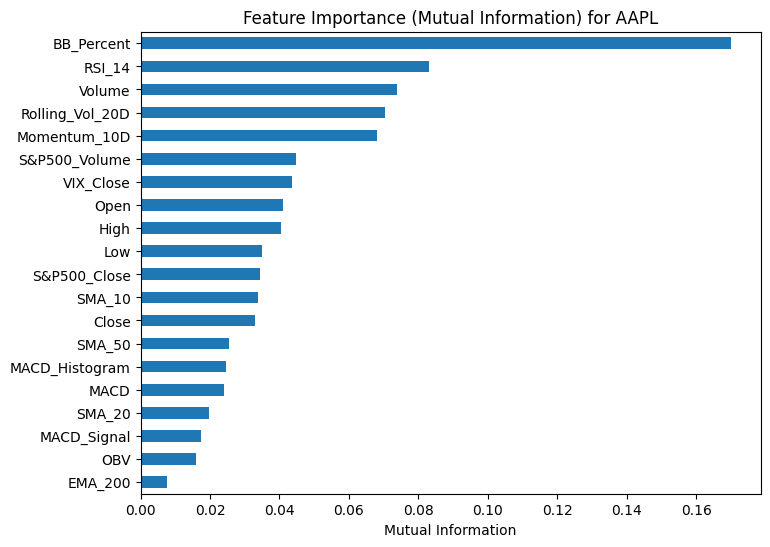

In [22]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt

# --- Select one ticker at a time (e.g. AAPL) ---
ticker = 'AAPL'
df = level_2_data[level_2_data['Ticker'] == ticker].copy().dropna()

target_col = 'Daily_Return'
feature_cols = [col for col in df.columns if col not in ['Date', 'Ticker', target_col]]

X = df[feature_cols]
y = df[target_col]

# --- Compute Correlation (linear dependency) ---
correlations = X.corrwith(y)

# --- Compute Mutual Information (nonlinear dependency) ---
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_cols)

# --- Combine & visualize ---
feature_importance_df = pd.DataFrame({
    'Correlation': correlations,
    'Mutual_Information': mi_series
}).sort_values(by='Mutual_Information', ascending=False)

print("\nTop features by Mutual Information (nonlinear relationship):")
print(feature_importance_df.head(10))

# --- Plot ---
feature_importance_df['Mutual_Information'].sort_values(ascending=True).plot.barh(figsize=(8,6))
plt.title(f"Feature Importance (Mutual Information) for {ticker}")
plt.xlabel("Mutual Information")
plt.show()



Top features by Mutual Information (nonlinear relationship):
                 Correlation  Mutual_Information
Volume              0.005360            0.210071
BB_Percent          0.420277            0.156514
RSI_14              0.330977            0.083175
VIX_Close          -0.086865            0.081989
Momentum_10D        0.218095            0.060119
Rolling_Vol_20D     0.018750            0.059840
SMA_50             -0.011093            0.040998
S&P500_Close        0.002139            0.033998
EMA_200            -0.010660            0.031455
OBV                 0.006804            0.026795


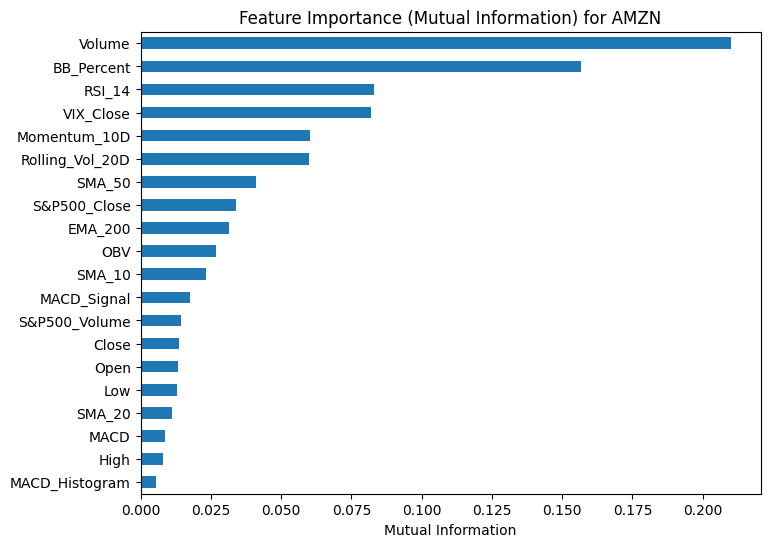

In [23]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt

# --- Select one ticker at a time (e.g. AAPL) ---
ticker = 'AMZN'
df = level_2_data[level_2_data['Ticker'] == ticker].copy().dropna()

target_col = 'Daily_Return'
feature_cols = [col for col in df.columns if col not in ['Date', 'Ticker', target_col]]

X = df[feature_cols]
y = df[target_col]

# --- Compute Correlation (linear dependency) ---
correlations = X.corrwith(y)

# --- Compute Mutual Information (nonlinear dependency) ---
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_cols)

# --- Combine & visualize ---
feature_importance_df = pd.DataFrame({
    'Correlation': correlations,
    'Mutual_Information': mi_series
}).sort_values(by='Mutual_Information', ascending=False)

print("\nTop features by Mutual Information (nonlinear relationship):")
print(feature_importance_df.head(10))

# --- Plot ---
feature_importance_df['Mutual_Information'].sort_values(ascending=True).plot.barh(figsize=(8,6))
plt.title(f"Feature Importance (Mutual Information) for {ticker}")
plt.xlabel("Mutual Information")
plt.show()


**XGBoost Fetaures**


Test MSE for AMZN: 2.621630


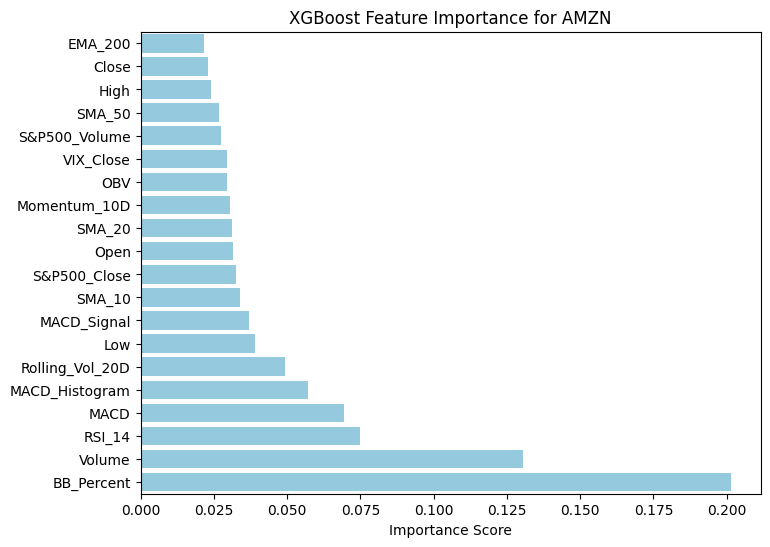


Top features by XGBoost importance:
BB_Percent         0.201507
Volume             0.130619
RSI_14             0.074738
MACD               0.069388
MACD_Histogram     0.057249
Rolling_Vol_20D    0.049166
Low                0.039025
MACD_Signal        0.036824
SMA_10             0.034013
S&P500_Close       0.032725
dtype: float32


In [24]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# --- Same dataset (AAPL example) ---
X = df[feature_cols]
y = df[target_col]

# --- Optional: scale data (XGBoost handles unscaled inputs well, but you can standardize if you prefer) ---
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

# --- Use TimeSeriesSplit for time-safe validation ---
tscv = TimeSeriesSplit(n_splits=5)

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train using the last fold (so it sees early data first)
for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred = xgb_model.predict(X_test)
print(f"\nTest MSE for {ticker}: {mean_squared_error(y_test, y_pred):.6f}")

# --- Feature importance ---
importance = pd.Series(xgb_model.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=True)

# --- Plot ---
plt.figure(figsize=(8,6))
sns.barplot(x=importance, y=importance.index, orient='h', color='skyblue')
plt.title(f"XGBoost Feature Importance for {ticker}")
plt.xlabel("Importance Score")
plt.show()

print("\nTop features by XGBoost importance:")
print(importance.sort_values(ascending=False).head(10))


In [25]:
level_2_data.head()

,Date,Ticker,Close,Open,High,Low,Volume,Daily_Return,Rolling_Vol_20D,Momentum_10D,...,EMA_200,RSI_14,MACD,MACD_Signal,MACD_Histogram,BB_Percent,OBV,S&P500_Close,S&P500_Volume,VIX_Close
0,2009-12-31,AAPL,6.444381,7.611786,7.619643,7.520000,352410800,NaN,NaN,NaN,...,6.444381,NaN,0.0,0.0,0.0,NaN,0.0,1115.099976,2.076990e+09,21.68
1,2009-12-31,ADBE,36.779999,37.169998,37.209999,36.700001,2900400,NaN,NaN,NaN,...,36.779999,NaN,0.0,0.0,0.0,NaN,0.0,1115.099976,2.076990e+09,21.68
2,2009-12-31,AMZN,134.520004,6.854500,6.864000,6.726000,90460000,NaN,NaN,NaN,...,134.520004,NaN,0.0,0.0,0.0,NaN,0.0,1115.099976,2.076990e+09,21.68
3,2009-12-31,AVGO,13.908897,1.761000,1.829000,1.761000,5558000,NaN,NaN,NaN,...,13.908897,NaN,0.0,0.0,0.0,NaN,0.0,1115.099976,2.076990e+09,21.68
4,2009-12-31,BAC,12.931032,15.090000,15.240000,15.010000,94322600,NaN,NaN,NaN,...,12.931032,NaN,0.0,0.0,0.0,NaN,0.0,1115.099976,2.076990e+09,21.68


In [26]:
level_2_data = level_2_data.dropna().reset_index(drop=True)

Found 27 tickers: ['AAPL', 'ADBE', 'AMZN', 'AVGO', 'BAC', 'BRK-A', 'COST', 'CSCO', 'CVX', 'DIS', 'GOOG', 'HD', 'JNJ', 'JPM', 'KO', 'LLY', 'MA', 'MSFT', 'NVDA', 'PEP', 'PFE', 'PG', 'UNH', 'V', 'WFC', 'WMT', 'XOM']

Training AAPL...
  ✓ AAPL: RMSE=$67.66 | MAE=$58.74 | MAPE=48.49%

Training ADBE...
  ✓ ADBE: RMSE=$200.69 | MAE=$167.67 | MAPE=32.48%

Training AMZN...
  ✓ AMZN: RMSE=$1180.98 | MAE=$1020.50 | MAPE=32.37%

Training AVGO...
  ✓ AVGO: RMSE=$155.07 | MAE=$118.91 | MAPE=26.69%

Training BAC...
  ✓ BAC: RMSE=$9.37 | MAE=$7.30 | MAPE=20.29%

Training BRK-A...
  ✓ BRK-A: RMSE=$68683.63 | MAE=$52072.25 | MAPE=13.50%

Training COST...
  ✓ COST: RMSE=$116.73 | MAE=$91.37 | MAPE=22.97%

Training CSCO...
  ✓ CSCO: RMSE=$6.94 | MAE=$6.19 | MAPE=14.28%

Training CVX...
  ✓ CVX: RMSE=$12.94 | MAE=$9.48 | MAPE=12.04%

Training DIS...
  ✓ DIS: RMSE=$29.28 | MAE=$24.52 | MAPE=15.97%

Training GOOG...
  ✓ GOOG: RMSE=$926.95 | MAE=$711.35 | MAPE=31.70%

Training HD...
  ✓ HD: RMSE=$90.15 | MAE=

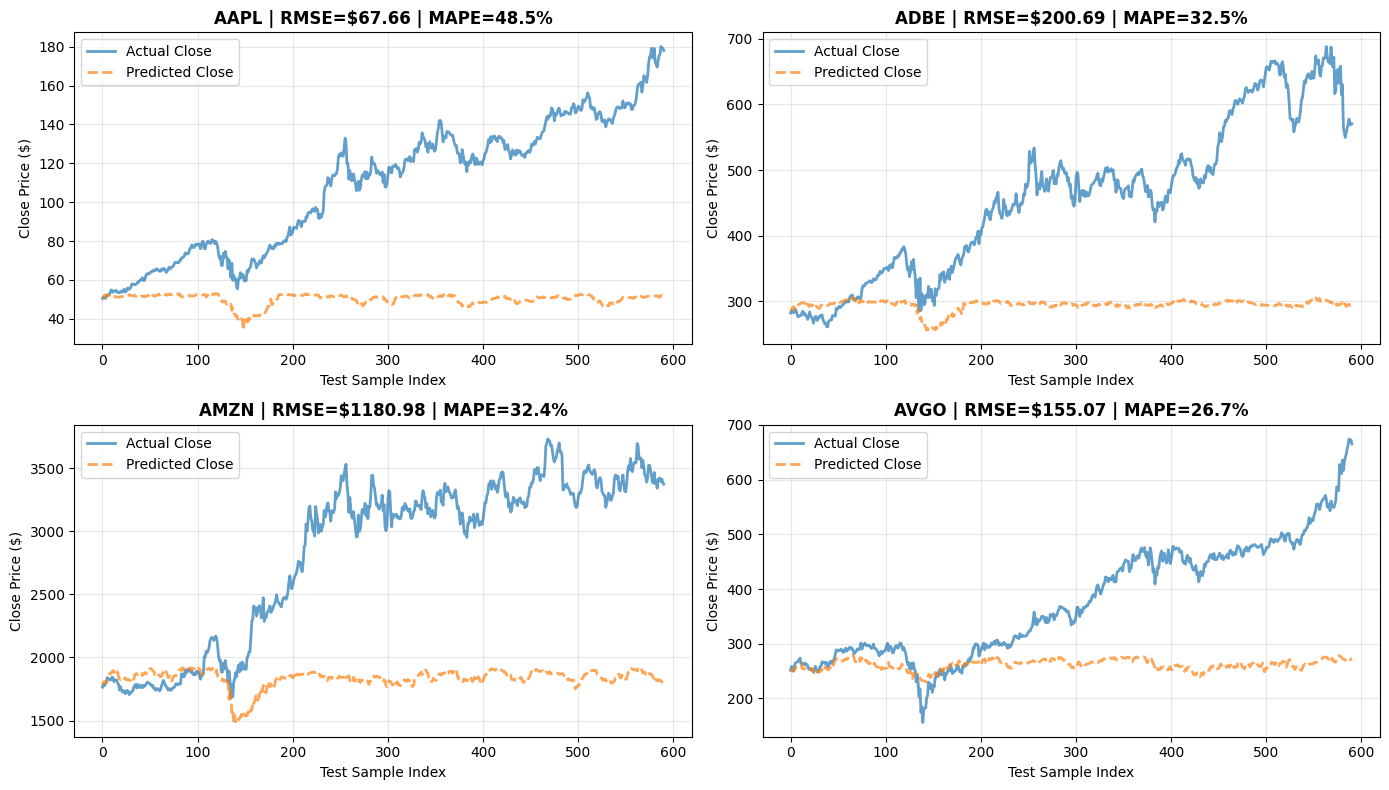

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
SELECTED_FEATURES = [
    'BB_Percent', 'RSI_14', 'Volume', 'MACD', 'MACD_Histogram',
    'Rolling_Vol_20D', 'Momentum_10D', 'EMA_200',
    'S&P500_Close', 'VIX_Close'
]
LOOKBACK_WINDOW = 20
TEST_SIZE = 0.2


def prepare_ticker_data(df, ticker, lookback_window, test_size):
    """Prepares X and y for one ticker - predicting CLOSE PRICE directly."""
    stock_df = df[df['Ticker'] == ticker].copy()
    stock_df.sort_values(by='Date', inplace=True)
    stock_df.dropna(subset=SELECTED_FEATURES + ['Close'], inplace=True)

    if len(stock_df) < lookback_window + 50:
        return None

    # Create lookback windows to predict NEXT day's close price
    X, y = [], []
    for i in range(len(stock_df) - lookback_window - 1):  # -1 to have next day available
        X_window = stock_df.iloc[i : i + lookback_window][SELECTED_FEATURES].values
        y_target = stock_df.iloc[i + lookback_window]['Close']  # Predict this day's close
        X.append(X_window)
        y.append(y_target)

    X = np.array(X)
    y = np.array(y)

    # Flatten windows for XGBoost (2D shape: samples x features*lookback)
    n_samples, n_timesteps, n_features = X.shape
    X = X.reshape(n_samples, n_timesteps * n_features)

    # Split into train/test (chronological)
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    # Scale X only (NOT y, since we want actual price predictions)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test, scaler


def train_and_evaluate(df, tickers, lookback_window, test_size):
    """Trains and evaluates XGBoost for each ticker."""
    results = {}

    for ticker in tickers:
        print(f"\nTraining {ticker}...")
        data = prepare_ticker_data(df, ticker, lookback_window, test_size)
        if data is None:
            print(f"  ⚠️  Skipping {ticker} (insufficient data).")
            continue

        X_train, X_test, y_train, y_test, scaler = data

        # XGBoost model
        model = XGBRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbosity=0
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Calculate metrics in dollars (actual prices)
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        
        # Calculate percentage error for context
        mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

        results[ticker] = {
            'model': model,
            'scaler': scaler,
            'mse': mse,
            'mae': mae,
            'rmse': rmse,
            'mape': mape,
            'y_test': y_test,
            'y_pred': y_pred
        }

        print(f"  ✓ {ticker}: RMSE=${rmse:.2f} | MAE=${mae:.2f} | MAPE={mape:.2f}%")

    return results


def plot_results(results, tickers_to_plot):
    """Plots predicted vs actual close prices for selected tickers."""
    n_plots = len(tickers_to_plot)
    n_cols = 2
    n_rows = (n_plots + 1) // 2
    
    plt.figure(figsize=(14, 4 * n_rows))

    for i, ticker in enumerate(tickers_to_plot, 1):
        if ticker not in results:
            print(f"Skipping plot for {ticker} (no results)")
            continue

        y_test = results[ticker]['y_test']
        y_pred = results[ticker]['y_pred']

        plt.subplot(n_rows, n_cols, i)
        plt.plot(y_test, label='Actual Close', linewidth=2, alpha=0.7)
        plt.plot(y_pred, label='Predicted Close', linewidth=2, alpha=0.7, linestyle='--')
        plt.title(f"{ticker} | RMSE=${results[ticker]['rmse']:.2f} | MAPE={results[ticker]['mape']:.1f}%", 
                  fontsize=12, fontweight='bold')
        plt.xlabel('Test Sample Index')
        plt.ylabel('Close Price ($)')
        plt.legend()
        plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def print_summary_table(results):
    """Prints a summary table of all ticker results."""
    print("\n" + "="*80)
    print("SUMMARY: All Tickers Performance")
    print("="*80)
    print(f"{'Ticker':<10} {'RMSE ($)':<12} {'MAE ($)':<12} {'MAPE (%)':<12} {'Avg Price ($)':<15}")
    print("-"*80)
    
    for ticker in sorted(results.keys()):
        r = results[ticker]
        avg_price = np.mean(r['y_test'])
        print(f"{ticker:<10} {r['rmse']:<12.2f} {r['mae']:<12.2f} {r['mape']:<12.2f} {avg_price:<15.2f}")
    
    print("="*80)


# --- MAIN EXECUTION ---

# (1) Filter dataset to keep only selected features + target
filtered_df = level_2_data[['Date', 'Ticker', 'Close'] + SELECTED_FEATURES].copy()
filtered_df.dropna(inplace=True)

# (2) Get all available tickers
all_tickers = sorted(filtered_df['Ticker'].unique())
print(f"Found {len(all_tickers)} tickers: {all_tickers}")

# (3) Train models for ALL tickers
results = train_and_evaluate(filtered_df, all_tickers, LOOKBACK_WINDOW, TEST_SIZE)

# (4) Print summary table
print_summary_table(results)

# (5) Plot predictions for first 4 tickers with results
tickers_to_plot = [t for t in all_tickers if t in results][:4]
plot_results(results, tickers_to_plot)

**N-Beats**

Using device: cuda
Found 27 tickers: ['AAPL', 'ADBE', 'AMZN', 'AVGO', 'BAC', 'BRK-A', 'COST', 'CSCO', 'CVX', 'DIS', 'GOOG', 'HD', 'JNJ', 'JPM', 'KO', 'LLY', 'MA', 'MSFT', 'NVDA', 'PEP', 'PFE', 'PG', 'UNH', 'V', 'WFC', 'WMT', 'XOM']

Training AAPL...
    Epoch 10/25, Loss: 0.0057
    Epoch 20/25, Loss: 0.0063
  ✓ AAPL: RMSE=$19.66 | MAE=$16.40 | MAPE=14.12%

Training ADBE...
    Epoch 10/25, Loss: 0.0093
    Epoch 20/25, Loss: 0.0125
  ✓ ADBE: RMSE=$40.12 | MAE=$30.50 | MAPE=6.38%

Training AMZN...
    Epoch 10/25, Loss: 0.0071
    Epoch 20/25, Loss: 0.0052
  ✓ AMZN: RMSE=$347.57 | MAE=$266.58 | MAPE=9.20%

Training AVGO...
    Epoch 10/25, Loss: 0.0146
    Epoch 20/25, Loss: 0.0043
  ✓ AVGO: RMSE=$40.71 | MAE=$31.70 | MAPE=8.48%

Training BAC...
    Epoch 10/25, Loss: 0.0056
    Epoch 20/25, Loss: 0.0054
  ✓ BAC: RMSE=$3.29 | MAE=$2.59 | MAPE=8.64%

Training BRK-A...
    Epoch 10/25, Loss: 0.0069
    Epoch 20/25, Loss: 0.0080
  ✓ BRK-A: RMSE=$28017.86 | MAE=$18862.76 | MAPE=5.88%

Trai

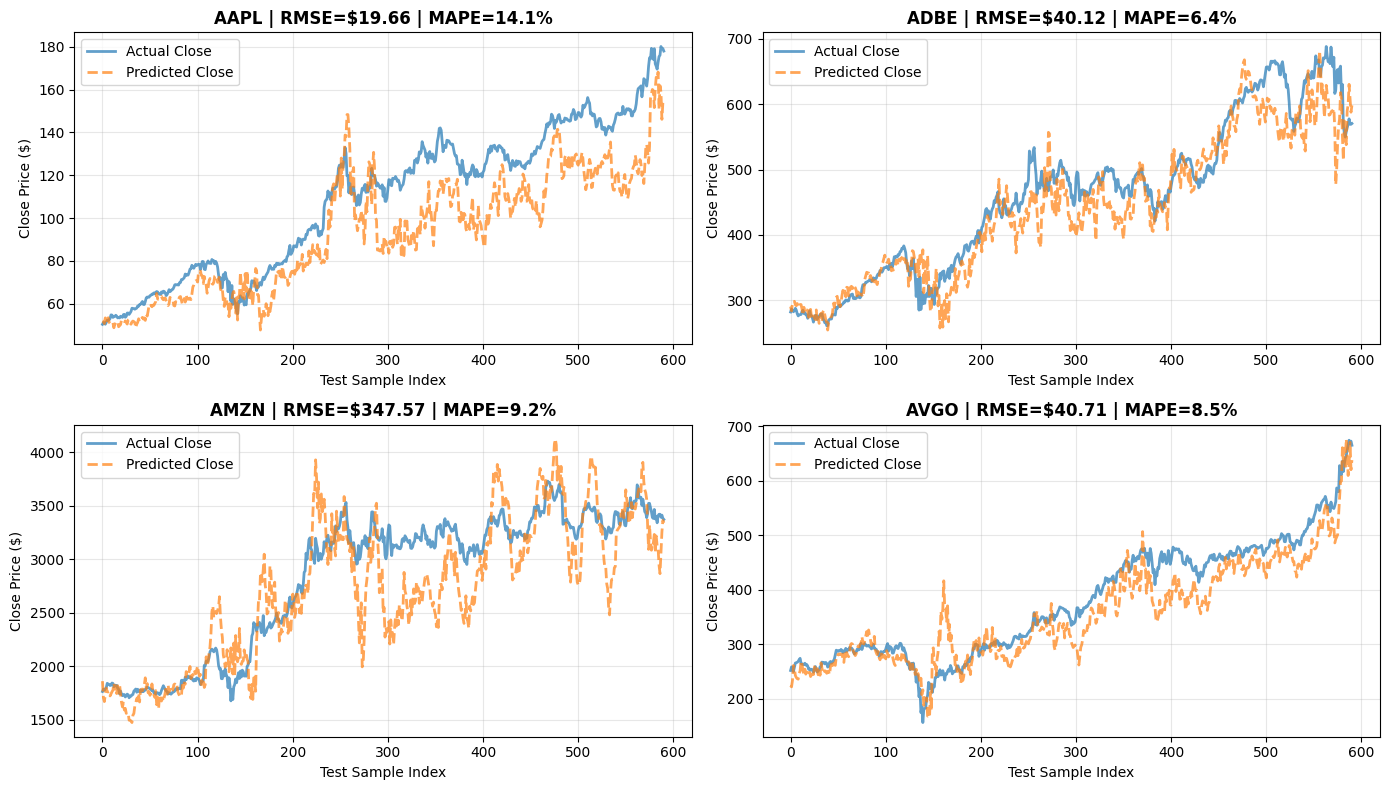

In [30]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
SELECTED_FEATURES = [
    'BB_Percent', 'RSI_14', 'Volume', 'MACD', 'MACD_Histogram',
    'Rolling_Vol_20D', 'Momentum_10D', 'EMA_200',
    'S&P500_Close', 'VIX_Close'
]
LOOKBACK_WINDOW = 20
TEST_SIZE = 0.2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# N-BEATS Hyperparameters
STACK_TYPES = ['trend', 'seasonality']
NUM_BLOCKS_PER_STACK = 3
HIDDEN_LAYER_UNITS = 256
THETA_HIDDEN_UNITS = [128, 128]
EPOCHS = 25
BATCH_SIZE = 32
LEARNING_RATE = 0.001


class NBeatsBlock(nn.Module):
    """Single N-BEATS block with forward/backward cast."""
    def __init__(self, input_size, theta_size, basis_function, hidden_units):
        super().__init__()
        self.input_size = input_size
        self.theta_size = theta_size
        self.basis_function = basis_function
        
        # Fully connected stack
        layers = []
        prev_units = input_size
        for units in hidden_units:
            layers.append(nn.Linear(prev_units, units))
            layers.append(nn.ReLU())
            prev_units = units
        self.fc_stack = nn.Sequential(*layers)
        
        # Theta layers for backcast and forecast
        self.theta_b = nn.Linear(prev_units, theta_size)
        self.theta_f = nn.Linear(prev_units, theta_size)
        
    def forward(self, x):
        # x shape: (batch, input_size)
        h = self.fc_stack(x)
        theta_b = self.theta_b(h)
        theta_f = self.theta_f(h)
        
        backcast = self.basis_function(theta_b, is_backcast=True)
        forecast = self.basis_function(theta_f, is_backcast=False)
        
        return backcast, forecast


class TrendBasis(nn.Module):
    """Polynomial trend basis function."""
    def __init__(self, degree, backcast_size, forecast_size):
        super().__init__()
        self.degree = degree
        self.backcast_size = backcast_size
        self.forecast_size = forecast_size
        
    def forward(self, theta, is_backcast):
        size = self.backcast_size if is_backcast else self.forecast_size
        # Generate polynomial basis: [1, t, t^2, ..., t^p]
        t = torch.arange(size, dtype=torch.float32, device=theta.device) / size
        basis = torch.stack([t ** i for i in range(self.degree)], dim=1)  # (size, degree)
        
        # theta shape: (batch, degree), basis: (size, degree)
        # output: (batch, size)
        return torch.matmul(theta, basis.T)


class SeasonalityBasis(nn.Module):
    """Fourier seasonality basis function."""
    def __init__(self, harmonics, backcast_size, forecast_size):
        super().__init__()
        self.harmonics = harmonics
        self.backcast_size = backcast_size
        self.forecast_size = forecast_size
        
    def forward(self, theta, is_backcast):
        size = self.backcast_size if is_backcast else self.forecast_size
        # Generate Fourier basis: [cos(2πt), sin(2πt), cos(4πt), sin(4πt), ...]
        t = torch.arange(size, dtype=torch.float32, device=theta.device) / size
        basis = []
        for i in range(1, self.harmonics + 1):
            basis.append(torch.cos(2 * np.pi * i * t))
            basis.append(torch.sin(2 * np.pi * i * t))
        basis = torch.stack(basis, dim=1)  # (size, 2*harmonics)
        
        # theta shape: (batch, 2*harmonics), basis: (size, 2*harmonics)
        return torch.matmul(theta, basis.T)


class NBeatsNet(nn.Module):
    """Modified N-BEATS network for multivariate input."""
    def __init__(self, input_size, forecast_size, stack_types, num_blocks, 
                 hidden_units, theta_units):
        super().__init__()
        self.forecast_size = forecast_size
        self.stacks = nn.ModuleList()
        
        for stack_type in stack_types:
            blocks = []
            for _ in range(num_blocks):
                if stack_type == 'trend':
                    degree = 3
                    basis = lambda theta, is_backcast: TrendBasis(
                        degree, input_size, forecast_size
                    )(theta, is_backcast)
                    theta_size = degree
                elif stack_type == 'seasonality':
                    harmonics = input_size // 2
                    basis = lambda theta, is_backcast, h=harmonics: SeasonalityBasis(
                        h, input_size, forecast_size
                    )(theta, is_backcast)
                    theta_size = 2 * harmonics
                else:  # generic
                    theta_size = input_size + forecast_size
                    basis = lambda theta, is_backcast: self._generic_basis(
                        theta, input_size, forecast_size, is_backcast
                    )
                
                block = NBeatsBlock(input_size, theta_size, basis, theta_units)
                blocks.append(block)
            self.stacks.append(nn.ModuleList(blocks))
    
    def _generic_basis(self, theta, backcast_size, forecast_size, is_backcast):
        if is_backcast:
            return theta[:, :backcast_size]
        else:
            return theta[:, backcast_size:]
    
    def forward(self, x):
        # x shape: (batch, lookback * n_features) - flatten multivariate input
        residual = x
        forecast = torch.zeros(x.size(0), self.forecast_size, device=x.device)
        
        for stack in self.stacks:
            for block in stack:
                backcast, block_forecast = block(residual)
                residual = residual - backcast
                forecast = forecast + block_forecast
        
        return forecast


class StockDataset(Dataset):
    """PyTorch dataset for stock data."""
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def prepare_ticker_data(df, ticker, lookback_window, test_size):
    """Prepares X and y for one ticker."""
    stock_df = df[df['Ticker'] == ticker].copy()
    stock_df.sort_values(by='Date', inplace=True)
    stock_df.dropna(subset=SELECTED_FEATURES + ['Close'], inplace=True)

    if len(stock_df) < lookback_window + 50:
        return None

    # Create lookback windows
    X, y = [], []
    for i in range(len(stock_df) - lookback_window - 1):
        X_window = stock_df.iloc[i : i + lookback_window][SELECTED_FEATURES].values
        y_target = stock_df.iloc[i + lookback_window]['Close']
        X.append(X_window)
        y.append(y_target)

    X = np.array(X)
    y = np.array(y)

    # Flatten windows (batch, timesteps, features) -> (batch, timesteps*features)
    n_samples, n_timesteps, n_features = X.shape
    X = X.reshape(n_samples, n_timesteps * n_features)

    # Split train/test
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    # Scale features
    scaler_X = StandardScaler()
    X_train = scaler_X.fit_transform(X_train)
    X_test = scaler_X.transform(X_test)
    
    # Scale target (helps training stability)
    scaler_y = StandardScaler()
    y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

    return X_train, X_test, y_train, y_test, y_test_scaled, scaler_X, scaler_y


def train_nbeats(X_train, y_train, input_size, forecast_size=1):
    """Train N-BEATS model."""
    model = NBeatsNet(
        input_size=input_size,
        forecast_size=forecast_size,
        stack_types=STACK_TYPES,
        num_blocks=NUM_BLOCKS_PER_STACK,
        hidden_units=[HIDDEN_LAYER_UNITS] * 4,
        theta_units=THETA_HIDDEN_UNITS
    ).to(DEVICE)
    
    dataset = StockDataset(X_train, y_train)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    model.train()
    for epoch in range(EPOCHS):
        total_loss = 0
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            
            optimizer.zero_grad()
            y_pred = model(X_batch).squeeze()
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        if (epoch + 1) % 10 == 0:
            avg_loss = total_loss / len(dataloader)
            print(f"    Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")
    
    return model


def train_and_evaluate(df, tickers, lookback_window, test_size):
    """Trains and evaluates N-BEATS for each ticker."""
    results = {}

    for ticker in tickers:
        print(f"\nTraining {ticker}...")
        data = prepare_ticker_data(df, ticker, lookback_window, test_size)
        if data is None:
            print(f"  ⚠️  Skipping {ticker} (insufficient data).")
            continue

        X_train, X_test, y_train_scaled, y_test, y_test_scaled, scaler_X, scaler_y = data
        
        # Train model
        input_size = X_train.shape[1]
        model = train_nbeats(X_train, y_train_scaled, input_size)
        
        # Evaluate
        model.eval()
        with torch.no_grad():
            X_test_tensor = torch.FloatTensor(X_test).to(DEVICE)
            y_pred_scaled = model(X_test_tensor).cpu().numpy().squeeze()
        
        # Inverse transform predictions back to original scale
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        
        # Calculate metrics
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

        results[ticker] = {
            'model': model,
            'scaler_X': scaler_X,
            'scaler_y': scaler_y,
            'mse': mse,
            'mae': mae,
            'rmse': rmse,
            'mape': mape,
            'y_test': y_test,
            'y_pred': y_pred
        }

        print(f"  ✓ {ticker}: RMSE=${rmse:.2f} | MAE=${mae:.2f} | MAPE={mape:.2f}%")

    return results


def plot_results(results, tickers_to_plot):
    """Plots predicted vs actual close prices."""
    n_plots = len(tickers_to_plot)
    n_cols = 2
    n_rows = (n_plots + 1) // 2
    
    plt.figure(figsize=(14, 4 * n_rows))

    for i, ticker in enumerate(tickers_to_plot, 1):
        if ticker not in results:
            continue

        y_test = results[ticker]['y_test']
        y_pred = results[ticker]['y_pred']

        plt.subplot(n_rows, n_cols, i)
        plt.plot(y_test, label='Actual Close', linewidth=2, alpha=0.7)
        plt.plot(y_pred, label='Predicted Close', linewidth=2, alpha=0.7, linestyle='--')
        plt.title(f"{ticker} | RMSE=${results[ticker]['rmse']:.2f} | MAPE={results[ticker]['mape']:.1f}%", 
                  fontsize=12, fontweight='bold')
        plt.xlabel('Test Sample Index')
        plt.ylabel('Close Price ($)')
        plt.legend()
        plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def print_summary_table(results):
    """Prints summary table."""
    print("\n" + "="*80)
    print("SUMMARY: N-BEATS Performance")
    print("="*80)
    print(f"{'Ticker':<10} {'RMSE ($)':<12} {'MAE ($)':<12} {'MAPE (%)':<12} {'Avg Price ($)':<15}")
    print("-"*80)
    
    for ticker in sorted(results.keys()):
        r = results[ticker]
        avg_price = np.mean(r['y_test'])
        print(f"{ticker:<10} {r['rmse']:<12.2f} {r['mae']:<12.2f} {r['mape']:<12.2f} {avg_price:<15.2f}")
    
    print("="*80)


# --- MAIN EXECUTION ---
print(f"Using device: {DEVICE}")

# Prepare data
filtered_df = level_2_data[['Date', 'Ticker', 'Close'] + SELECTED_FEATURES].copy()
filtered_df.dropna(inplace=True)

# Get all tickers
all_tickers = sorted(filtered_df['Ticker'].unique())
print(f"Found {len(all_tickers)} tickers: {all_tickers}")

# Train models
results = train_and_evaluate(filtered_df, all_tickers, LOOKBACK_WINDOW, TEST_SIZE)

# Print summary and plot
print_summary_table(results)
tickers_to_plot = [t for t in all_tickers if t in results][:4]
plot_results(results, tickers_to_plot)

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
SELECTED_FEATURES = [
    'BB_Percent', 'RSI_14', 'Volume', 'MACD', 'MACD_Histogram',
    'Rolling_Vol_20D', 'Momentum_10D', 'EMA_200',
    'S&P500_Close', 'VIX_Close'
]
LOOKBACK_WINDOW = 20
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# N-BEATS Parameters
STACK_TYPES = ['trend', 'seasonality']
NUM_BLOCKS_PER_STACK = 3
HIDDEN_LAYER_UNITS = 256
THETA_HIDDEN_UNITS = [128, 128]
EPOCHS = 25
BATCH_SIZE = 32
LEARNING_RATE = 0.001

# Backtesting Parameters
INITIAL_TRAINING_YEARS = 3
REBALANCE_FREQUENCY_MONTHS = 3  # Quarterly
TRANSACTION_COST_BPS = 15  # 15 basis points per trade
RISK_FREE_RATE = 0.04
TRADING_DAYS_PER_YEAR = 252
INITIAL_CAPITAL = 100000  # $100k


# ============================================================================
# N-BEATS MODEL COMPONENTS (Same as before)
# ============================================================================

class TrendBasis(nn.Module):
    def __init__(self, degree, backcast_size, forecast_size):
        super().__init__()
        self.degree = degree
        self.backcast_size = backcast_size
        self.forecast_size = forecast_size
        
    def forward(self, theta, is_backcast):
        size = self.backcast_size if is_backcast else self.forecast_size
        t = torch.arange(size, dtype=torch.float32, device=theta.device) / size
        basis = torch.stack([t ** i for i in range(self.degree)], dim=1)
        return torch.matmul(theta, basis.T)


class SeasonalityBasis(nn.Module):
    def __init__(self, harmonics, backcast_size, forecast_size):
        super().__init__()
        self.harmonics = harmonics
        self.backcast_size = backcast_size
        self.forecast_size = forecast_size
        
    def forward(self, theta, is_backcast):
        size = self.backcast_size if is_backcast else self.forecast_size
        t = torch.arange(size, dtype=torch.float32, device=theta.device) / size
        basis = []
        for i in range(1, self.harmonics + 1):
            basis.append(torch.cos(2 * np.pi * i * t))
            basis.append(torch.sin(2 * np.pi * i * t))
        basis = torch.stack(basis, dim=1)
        return torch.matmul(theta, basis.T)


class NBeatsBlock(nn.Module):
    def __init__(self, input_size, theta_size, basis_function, hidden_units):
        super().__init__()
        self.input_size = input_size
        self.theta_size = theta_size
        self.basis_function = basis_function
        
        layers = []
        prev_units = input_size
        for units in hidden_units:
            layers.append(nn.Linear(prev_units, units))
            layers.append(nn.ReLU())
            prev_units = units
        self.fc_stack = nn.Sequential(*layers)
        
        self.theta_b = nn.Linear(prev_units, theta_size)
        self.theta_f = nn.Linear(prev_units, theta_size)
        
    def forward(self, x):
        h = self.fc_stack(x)
        theta_b = self.theta_b(h)
        theta_f = self.theta_f(h)
        
        backcast = self.basis_function(theta_b, is_backcast=True)
        forecast = self.basis_function(theta_f, is_backcast=False)
        
        return backcast, forecast


class NBeatsNet(nn.Module):
    def __init__(self, input_size, forecast_size, stack_types, num_blocks, 
                 hidden_units, theta_units):
        super().__init__()
        self.forecast_size = forecast_size
        self.stacks = nn.ModuleList()
        
        for stack_type in stack_types:
            blocks = []
            for _ in range(num_blocks):
                if stack_type == 'trend':
                    degree = 3
                    basis = lambda theta, is_backcast: TrendBasis(
                        degree, input_size, forecast_size
                    )(theta, is_backcast)
                    theta_size = degree
                elif stack_type == 'seasonality':
                    harmonics = input_size // 2
                    basis = lambda theta, is_backcast, h=harmonics: SeasonalityBasis(
                        h, input_size, forecast_size
                    )(theta, is_backcast)
                    theta_size = 2 * harmonics
                else:
                    theta_size = input_size + forecast_size
                    basis = lambda theta, is_backcast: self._generic_basis(
                        theta, input_size, forecast_size, is_backcast
                    )
                
                block = NBeatsBlock(input_size, theta_size, basis, theta_units)
                blocks.append(block)
            self.stacks.append(nn.ModuleList(blocks))
    
    def _generic_basis(self, theta, backcast_size, forecast_size, is_backcast):
        if is_backcast:
            return theta[:, :backcast_size]
        else:
            return theta[:, backcast_size:]
    
    def forward(self, x):
        residual = x
        forecast = torch.zeros(x.size(0), self.forecast_size, device=x.device)
        
        for stack in self.stacks:
            for block in stack:
                backcast, block_forecast = block(residual)
                residual = residual - backcast
                forecast = forecast + block_forecast
        
        return forecast


class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ============================================================================
# DATA PREPARATION & MODEL TRAINING
# ============================================================================

def prepare_ticker_data_for_period(df, ticker, end_date, lookback_window):
    """Prepare data for one ticker up to end_date."""
    stock_df = df[df['Ticker'] == ticker].copy()
    stock_df.sort_values(by='Date', inplace=True)
    
    # Filter up to end_date
    stock_df = stock_df[stock_df['Date'] <= end_date]
    stock_df.dropna(subset=SELECTED_FEATURES + ['Close'], inplace=True)

    if len(stock_df) < lookback_window + 50:
        return None

    # Create lookback windows
    X, y = [], []
    for i in range(len(stock_df) - lookback_window - 1):
        X_window = stock_df.iloc[i : i + lookback_window][SELECTED_FEATURES].values
        y_target = stock_df.iloc[i + lookback_window]['Close']
        X.append(X_window)
        y.append(y_target)

    X = np.array(X)
    y = np.array(y)

    # Flatten windows
    n_samples, n_timesteps, n_features = X.shape
    X = X.reshape(n_samples, n_timesteps * n_features)

    # Scale
    scaler_X = StandardScaler()
    X = scaler_X.fit_transform(X)
    
    scaler_y = StandardScaler()
    y = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

    return X, y, scaler_X, scaler_y


def train_nbeats_ticker(X, y, input_size, verbose=False):
    """Train N-BEATS model for one ticker."""
    model = NBeatsNet(
        input_size=input_size,
        forecast_size=1,
        stack_types=STACK_TYPES,
        num_blocks=NUM_BLOCKS_PER_STACK,
        hidden_units=[HIDDEN_LAYER_UNITS] * 4,
        theta_units=THETA_HIDDEN_UNITS
    ).to(DEVICE)
    
    dataset = StockDataset(X, y)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    model.train()
    for epoch in range(EPOCHS):
        total_loss = 0
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            
            optimizer.zero_grad()
            y_pred = model(X_batch).squeeze()
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        if verbose and (epoch + 1) % 10 == 0:
            avg_loss = total_loss / len(dataloader)
            print(f"      Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")
    
    return model


def predict_next_price(model, df, ticker, current_date, scaler_X, scaler_y):
    """Predict next day's price for a ticker."""
    stock_df = df[df['Ticker'] == ticker].copy()
    stock_df.sort_values(by='Date', inplace=True)
    stock_df = stock_df[stock_df['Date'] <= current_date]
    
    if len(stock_df) < LOOKBACK_WINDOW:
        return None
    
    # Get last lookback window
    X_window = stock_df.iloc[-LOOKBACK_WINDOW:][SELECTED_FEATURES].values
    X_window = X_window.reshape(1, -1)
    X_window = scaler_X.transform(X_window)
    
    # Predict
    model.eval()
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X_window).to(DEVICE)
        y_pred_scaled = model(X_tensor).cpu().numpy().squeeze()
    
    # Inverse transform
    y_pred = scaler_y.inverse_transform([[y_pred_scaled]])[0][0]
    
    return y_pred


# ============================================================================
# PORTFOLIO OPTIMIZATION
# ============================================================================

def calculate_ledoit_wolf_covariance(returns_df):
    """Calculate Ledoit-Wolf shrinkage covariance matrix."""
    lw = LedoitWolf()
    lw.fit(returns_df)
    return pd.DataFrame(lw.covariance_, index=returns_df.columns, columns=returns_df.columns)


def optimize_portfolio(expected_returns, cov_matrix, objective='sharpe'):
    """Optimize portfolio using SLSQP."""
    n_assets = len(expected_returns)
    init_weights = np.array([1.0 / n_assets] * n_assets)
    
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    bounds = tuple((0, 1) for _ in range(n_assets))
    
    if objective == 'sharpe':
        def objective_func(w):
            port_return = np.dot(w, expected_returns)
            port_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))
            annual_return = port_return * TRADING_DAYS_PER_YEAR
            annual_vol = port_vol * np.sqrt(TRADING_DAYS_PER_YEAR)
            sharpe = (annual_return - RISK_FREE_RATE) / annual_vol if annual_vol > 0 else 0
            return -sharpe
    elif objective == 'min_variance':
        def objective_func(w):
            return np.dot(w.T, np.dot(cov_matrix, w))
    elif objective == 'max_return':
        def objective_func(w):
            return -np.dot(w, expected_returns)
    else:
        raise ValueError("Unknown objective")
    
    result = minimize(objective_func, init_weights, method='SLSQP',
                     bounds=bounds, constraints=constraints, options={'maxiter': 1000})
    
    return result.x if result.success else init_weights


def calculate_transaction_costs(old_weights, new_weights, portfolio_value):
    """Calculate transaction costs based on turnover."""
    turnover = np.sum(np.abs(new_weights - old_weights))
    costs = turnover * portfolio_value * (TRANSACTION_COST_BPS / 10000)
    return costs


# ============================================================================
# BACKTESTING ENGINE
# ============================================================================

def run_walkforward_backtest(df, tickers, strategies=['max_sharpe', 'min_variance', 'equal_weight']):
    """Run walk-forward backtest with quarterly retraining."""
    
    print("\n" + "="*80)
    print("WALK-FORWARD BACKTESTING WITH N-BEATS")
    print("="*80)
    print(f"Tickers: {len(tickers)}")
    print(f"Rebalance Frequency: Every {REBALANCE_FREQUENCY_MONTHS} months")
    print(f"Transaction Costs: {TRANSACTION_COST_BPS} bps")
    print(f"Device: {DEVICE}")
    print("="*80)
    
    # Get all dates
    all_dates = sorted(df['Date'].unique())
    start_date = all_dates[0]
    end_date = all_dates[-1]
    
    # Calculate initial training end date
    initial_training_end = start_date + pd.DateOffset(years=INITIAL_TRAINING_YEARS)
    
    # Get rebalance dates (end of each quarter)
    rebalance_dates = pd.date_range(
        start=initial_training_end,
        end=end_date,
        freq=f'{REBALANCE_FREQUENCY_MONTHS}M'
    )
    rebalance_dates = [d for d in rebalance_dates if d in all_dates]
    
    print(f"\nBacktest Period: {initial_training_end.date()} to {end_date.date()}")
    print(f"Number of Rebalances: {len(rebalance_dates)}")
    
    # Initialize portfolios
    portfolio_values = {strategy: [INITIAL_CAPITAL] for strategy in strategies}
    portfolio_weights = {strategy: None for strategy in strategies}
    rebalance_history = []
    
    # Iterate through rebalance dates
    for i, rebalance_date in enumerate(rebalance_dates):
        print(f"\n{'='*80}")
        print(f"REBALANCE {i+1}/{len(rebalance_dates)}: {rebalance_date.date()}")
        print(f"{'='*80}")
        
        # Train models on all data up to rebalance_date
        print("\n🔄 Training N-BEATS models...")
        models = {}
        scalers = {}
        
        for j, ticker in enumerate(tickers, 1):
            print(f"  [{j}/{len(tickers)}] Training {ticker}...", end='')
            
            data = prepare_ticker_data_for_period(df, ticker, rebalance_date, LOOKBACK_WINDOW)
            if data is None:
                print(" ⚠️ Insufficient data, skipping.")
                continue
            
            X, y, scaler_X, scaler_y = data
            input_size = X.shape[1]
            
            model = train_nbeats_ticker(X, y, input_size, verbose=False)
            models[ticker] = model
            scalers[ticker] = (scaler_X, scaler_y)
            print(" ✓")
        
        # Get predictions for next period
        print("\n📊 Generating predictions...")
        predictions = {}
        current_prices = {}
        
        for ticker in models.keys():
            pred_price = predict_next_price(
                models[ticker], df, ticker, rebalance_date,
                scalers[ticker][0], scalers[ticker][1]
            )
            
            # Get current price
            ticker_data = df[(df['Ticker'] == ticker) & (df['Date'] == rebalance_date)]
            if len(ticker_data) > 0:
                current_price = ticker_data.iloc[0]['Close']
                predictions[ticker] = pred_price
                current_prices[ticker] = current_price
        
        # Calculate expected returns
        expected_returns = pd.Series({
            ticker: (predictions[ticker] - current_prices[ticker]) / current_prices[ticker]
            for ticker in predictions.keys()
        })
        
        print(f"  Generated predictions for {len(expected_returns)} tickers")
        print(f"  Expected returns range: {expected_returns.min():.2%} to {expected_returns.max():.2%}")
        
        # Calculate covariance using trailing 1 year of returns
        print("\n📈 Calculating Ledoit-Wolf covariance...")
        one_year_ago = rebalance_date - pd.DateOffset(years=1)
        returns_df = pd.DataFrame()
        
        for ticker in expected_returns.index:
            ticker_data = df[(df['Ticker'] == ticker) & 
                           (df['Date'] >= one_year_ago) & 
                           (df['Date'] <= rebalance_date)].copy()
            ticker_data.sort_values('Date', inplace=True)
            ticker_data['Return'] = ticker_data['Close'].pct_change()
            returns_df[ticker] = ticker_data['Return'].values
        
        returns_df.dropna(inplace=True)
        cov_matrix = calculate_ledoit_wolf_covariance(returns_df)
        
        # Optimize portfolios for each strategy
        print("\n🎯 Optimizing portfolios...")
        new_weights = {}
        
        for strategy in strategies:
            if strategy == 'equal_weight':
                n = len(expected_returns)
                new_weights[strategy] = pd.Series(
                    [1.0/n] * n, index=expected_returns.index
                )
            elif strategy == 'max_sharpe':
                weights = optimize_portfolio(expected_returns, cov_matrix, 'sharpe')
                new_weights[strategy] = pd.Series(weights, index=expected_returns.index)
            elif strategy == 'min_variance':
                weights = optimize_portfolio(expected_returns, cov_matrix, 'min_variance')
                new_weights[strategy] = pd.Series(weights, index=expected_returns.index)
        
        # Calculate transaction costs and update portfolio values
        print("\n💰 Calculating returns and costs...")
        
        # Get next rebalance date (or end date)
        if i < len(rebalance_dates) - 1:
            next_rebalance = rebalance_dates[i + 1]
        else:
            next_rebalance = end_date
        
        # Calculate returns over holding period
        holding_returns = {}
        for ticker in expected_returns.index:
            ticker_data = df[(df['Ticker'] == ticker) & 
                           (df['Date'] >= rebalance_date) & 
                           (df['Date'] <= next_rebalance)]
            if len(ticker_data) >= 2:
                start_price = ticker_data.iloc[0]['Close']
                end_price = ticker_data.iloc[-1]['Close']
                holding_returns[ticker] = (end_price - start_price) / start_price
            else:
                holding_returns[ticker] = 0
        
        holding_returns = pd.Series(holding_returns)
        
        for strategy in strategies:
            current_value = portfolio_values[strategy][-1]
            old_weights_vec = portfolio_weights[strategy]
            
            if old_weights_vec is None:
                old_weights_vec = pd.Series(0, index=new_weights[strategy].index)
            else:
                # Align old weights with new tickers
                old_weights_vec = old_weights_vec.reindex(new_weights[strategy].index, fill_value=0)
            
            # Calculate transaction costs
            costs = calculate_transaction_costs(
                old_weights_vec.values,
                new_weights[strategy].values,
                current_value
            )
            
            # Calculate portfolio return
            aligned_returns = holding_returns.reindex(new_weights[strategy].index, fill_value=0)
            portfolio_return = np.dot(new_weights[strategy].values, aligned_returns.values)
            
            # Update portfolio value
            new_value = current_value * (1 + portfolio_return) - costs
            portfolio_values[strategy].append(new_value)
            portfolio_weights[strategy] = new_weights[strategy]
            
            print(f"  {strategy:15s}: Return={portfolio_return:>7.2%}, Costs=${costs:>8.2f}, Value=${new_value:>12,.2f}")
        
        # Store rebalance info
        rebalance_history.append({
            'date': rebalance_date,
            'weights': new_weights.copy(),
            'expected_returns': expected_returns.copy(),
            'holding_returns': holding_returns.copy()
        })
    
    return portfolio_values, rebalance_history, rebalance_dates


def calculate_performance_metrics(portfolio_values, rebalance_dates):
    """Calculate performance metrics for each strategy."""
    metrics = {}
    
    for strategy, values in portfolio_values.items():
        returns = np.diff(values) / values[:-1]
        
        total_return = (values[-1] - values[0]) / values[0]
        n_periods = len(values) - 1
        years = n_periods * REBALANCE_FREQUENCY_MONTHS / 12
        annual_return = (1 + total_return) ** (1/years) - 1 if years > 0 else 0
        
        annual_vol = np.std(returns) * np.sqrt(12 / REBALANCE_FREQUENCY_MONTHS)
        sharpe = (annual_return - RISK_FREE_RATE) / annual_vol if annual_vol > 0 else 0
        
        # Maximum drawdown
        cumulative = np.array(values) / INITIAL_CAPITAL
        running_max = np.maximum.accumulate(cumulative)
        drawdown = (cumulative - running_max) / running_max
        max_drawdown = np.min(drawdown)
        
        metrics[strategy] = {
            'Total Return (%)': total_return * 100,
            'Annual Return (%)': annual_return * 100,
            'Annual Volatility (%)': annual_vol * 100,
            'Sharpe Ratio': sharpe,
            'Max Drawdown (%)': max_drawdown * 100,
            'Final Value ($)': values[-1]
        }
    
    return metrics


def plot_backtest_results(portfolio_values, rebalance_dates, metrics):
    """Plot backtest results."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Plot 1: Portfolio Values Over Time
    ax1 = axes[0, 0]
    for strategy, values in portfolio_values.items():
        dates_plot = [rebalance_dates[0]] + list(rebalance_dates)
        ax1.plot(dates_plot[:len(values)], values, label=strategy, linewidth=2, marker='o', markersize=4)
    ax1.set_title('Portfolio Value Over Time', fontweight='bold', fontsize=14)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Portfolio Value ($)')
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax1.axhline(y=INITIAL_CAPITAL, color='gray', linestyle='--', alpha=0.5, label='Initial Capital')
    
    # Plot 2: Performance Metrics Comparison
    ax2 = axes[0, 1]
    strategies = list(metrics.keys())
    x = np.arange(len(strategies))
    width = 0.25
    
    returns = [metrics[s]['Annual Return (%)'] for s in strategies]
    vols = [metrics[s]['Annual Volatility (%)'] for s in strategies]
    sharpes = [metrics[s]['Sharpe Ratio'] for s in strategies]
    
    ax2.bar(x - width, returns, width, label='Annual Return (%)', alpha=0.8)
    ax2.bar(x, vols, width, label='Annual Volatility (%)', alpha=0.8)
    ax2.bar(x + width, sharpes, width, label='Sharpe Ratio', alpha=0.8)
    
    ax2.set_title('Performance Metrics Comparison', fontweight='bold', fontsize=14)
    ax2.set_xticks(x)
    ax2.set_xticklabels(strategies, rotation=15)
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # Plot 3: Cumulative Returns
    ax3 = axes[1, 0]
    for strategy, values in portfolio_values.items():
        cumulative_returns = [(v / INITIAL_CAPITAL - 1) * 100 for v in values]
        dates_plot = [rebalance_dates[0]] + list(rebalance_dates)
        ax3.plot(dates_plot[:len(cumulative_returns)], cumulative_returns, 
                label=strategy, linewidth=2, marker='o', markersize=4)
    ax3.set_title('Cumulative Returns (%)', fontweight='bold', fontsize=14)
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Cumulative Return (%)')
    ax3.legend()
    ax3.grid(alpha=0.3)
    ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    
    # Plot 4: Summary Table
    ax4 = axes[1, 1]
    ax4.axis('tight')
    ax4.axis('off')
    
    table_data = []
    for strategy in strategies:
        row = [
            strategy,
            f"{metrics[strategy]['Annual Return (%)']:.2f}%",
            f"{metrics[strategy]['Annual Volatility (%)']:.2f}%",
            f"{metrics[strategy]['Sharpe Ratio']:.3f}",
            f"{metrics[strategy]['Max Drawdown (%)']:.2f}%",
            f"${metrics[strategy]['Final Value ($)']:,.0f}"
        ]
        table_data.append(row)
    
    table = ax4.table(cellText=table_data,
                     colLabels=['Strategy', 'Annual Return', 'Annual Vol', 'Sharpe', 'Max DD', 'Final Value'],
                     cellLoc='center',
                     loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    ax4.set_title('Performance Summary', fontweight='bold', fontsize=14, pad=20)
    
    plt.tight_layout()
    plt.show()


def print_summary_table(metrics):
    """Print performance summary table."""
    print("\n" + "="*100)
    print("BACKTEST PERFORMANCE SUMMARY")
    print("="*100)
    print(f"{'Strategy':<20} {'Annual Return':<15} {'Annual Vol':<15} {'Sharpe':<10} {'Max DD':<12} {'Final Value':<15}")
    print("-"*100)
    
    for strategy, m in metrics.items():
        print(f"{strategy:<20} {m['Annual Return (%)']:>13.2f}% {m['Annual Volatility (%)']:>13.2f}% "
              f"{m['Sharpe Ratio']:>8.3f} {m['Max Drawdown (%)']:>10.2f}% ${m['Final Value ($)']:>13,.0f}")
    
    print("="*100)


# ============================================================================
# MAIN EXECUTION
# ============================================================================

# Prepare data
filtered_df = level_2_data[['Date', 'Ticker', 'Close'] + SELECTED_FEATURES].copy()
filtered_df['Date'] = pd.to_datetime(filtered_df['Date'])
filtered_df.dropna(inplace=True)

# Get tickers
all_tickers = sorted(filtered_df['Ticker'].unique())
print(f"\nAvailable tickers: {all_tickers}")

# Run backtest
strategies = ['max_sharpe', 'min_variance', 'equal_weight']
portfolio_values, rebalance_history, rebalance_dates = run_walkforward_backtest(
    filtered_df, all_tickers, strategies
)

# Calculate metrics
metrics = calculate_performance_metrics(portfolio_values, rebalance_dates)

# Print and plot results
print_summary_table(metrics)
plot_backtest_results(portfolio_values, rebalance_dates, metrics)

print("\n✅ Walk-forward backtest complete!")

NameError: name 'level_2_data' is not defined

In [ ]:
print("Feature statistics BEFORE training:")
print(f"X_train min: {X_train.min()}")
print(f"X_train max: {X_train.max()}")
print(f"X_train mean: {X_train.mean()}")
print(f"X_train std: {X_train.std()}")

In [ ]:
print("="*50)
print("DATA DIAGNOSTICS")
print("="*50)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nX_train stats:")
print(f"  Min: {X_train.min():.4f}")
print(f"  Max: {X_train.max():.4f}")
print(f"  Mean: {X_train.mean():.4f}")
print(f"  Std: {X_train.std():.4f}")
print(f"\ny_train stats:")
print(f"  Min: {y_train.min():.4f}")
print(f"  Max: {y_train.max():.4f}")
print(f"  Mean: {y_train.mean():.4f}")
print(f"  Std: {y_train.std():.4f}")
print(f"\nData quality:")
print(f"  NaN in X: {np.isnan(X_train).sum()}")
print(f"  Inf in X: {np.isinf(X_train).sum()}")
print(f"  NaN in y: {np.isnan(y_train).sum()}")

In [ ]:
import matplotlib.pyplot as plt

# Plot first sequence
plt.figure(figsize=(15, 10))
for i in range(min(20, X_train.shape[2])):  # Plot first 20 features
    plt.subplot(5, 4, i+1)
    plt.plot(X_train[0, :, i])
    plt.title(f'Feature {i}')
    plt.tight_layout()
plt.show()

**LSTM**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys

def build_improved_lstm_model(input_shape):
    """
    Builds an LSTM model for stock return prediction.
    
    Args:
        input_shape (tuple): (timesteps, features), e.g., (20, 21)
    """
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),  # FIX: Use parameter
        Dropout(0.3),  # Increase dropout slightly
        
        LSTM(32, return_sequences=False),
        Dropout(0.3),
        
        Dense(32, activation='relu'),
        Dropout(0.2),
        
        Dense(1, activation='linear')  # Explicit linear activation
    ])
    
    # FIX: Lower learning rate + gradient clipping
    optimizer = Adam(learning_rate=0.0003, clipnorm=1.0)
    
    model.compile(
        loss='mean_squared_error', 
        optimizer=optimizer,
        metrics=['mae']  # Track MAE during training
    )
    
    return model

print("Imports complete and LSTM model function is defined.")

In [ ]:
# --- Training Loop (Fixed) ---
if 'univariate_datasets' not in locals():
    print("Error: 'univariate_datasets' not found.", file=sys.stderr)
else:
    all_metrics = {}
    tickers_to_train = list(univariate_datasets.keys())
    stocks_to_plot = tickers_to_train[:7]
    
    print(f"Starting training for {len(tickers_to_train)} separate LSTM models...")
    
    for ticker in tickers_to_train:
        print(f"\n{'='*60}")
        print(f"Training Model for {ticker}")
        print(f"{'='*60}")
        
        # Get data
        data = univariate_datasets[ticker]
        X_train = data['X_train']
        y_train = data['y_train']
        X_test = data['X_test']
        y_test = data['y_test']
        
        # Diagnostic prints
        print(f"X_train shape: {X_train.shape}")
        print(f"y_train range: [{y_train.min():.2f}, {y_train.max():.2f}]")
        
        # FIX: Use actual input shape
        input_shape = (X_train.shape[1], X_train.shape[2])
        
        # Build model
        model = build_improved_lstm_model(input_shape)
        
        # FIX: Better callbacks
        early_stopper = EarlyStopping(
            monitor='val_loss',
            patience=20,  # More patient
            min_delta=0.001,
            restore_best_weights=True,
            verbose=1
        )
        
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=7,
            min_lr=0.00001,
            verbose=1
        )
        
        # FIX: Use validation_split instead of test set
        history = model.fit(
            X_train, y_train,
            validation_split=0.2,  # Use 20% of training for validation
            epochs=100,
            batch_size=64,  # Larger batch size
            callbacks=[early_stopper, reduce_lr],
            verbose=1  # Show progress
        )
        
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"\nTraining complete. Best epoch: {best_epoch}")
        
        # Evaluate on TRUE test set
        y_pred = model.predict(X_test).squeeze()
        
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        
        # NEW: Check prediction variance
        pred_std = y_pred.std()
        actual_std = y_test.std()
        
        print(f"\n--- Metrics for {ticker} ---")
        print(f"Test MSE: {mse:.6f}")
        print(f"Test MAE: {mae:.6f} ({mae:.4f}%)")
        print(f"Prediction Std: {pred_std:.4f}% (Actual: {actual_std:.4f}%)")
        print(f"Variance Ratio: {pred_std/actual_std:.2%}")
        
        # Store metrics
        all_metrics[ticker] = {
            'MSE': mse,
            'MAE': mae,
            'MAE (%)': mae,
            'Pred_Std': pred_std,
            'Actual_Std': actual_std,
            'Variance_Ratio': pred_std / actual_std
        }
        
        # Plot if selected
        if ticker in stocks_to_plot:
            fig, axes = plt.subplots(2, 1, figsize=(14, 8))
            
            # Plot 1: Predictions
            axes[0].plot(y_test[:200], label='Actual Returns', alpha=0.8)
            axes[0].plot(y_pred[:200], label='Predicted Returns', linestyle='--')
            axes[0].set_title(f"Predictions vs. Actual for {ticker} (First 200 samples)")
            axes[0].set_xlabel("Test Sample Index")
            axes[0].set_ylabel("Daily Return (%)")
            axes[0].legend()
            axes[0].grid(True)
            
            # Plot 2: Training history
            axes[1].plot(history.history['loss'], label='Train Loss')
            axes[1].plot(history.history['val_loss'], label='Val Loss')
            axes[1].set_title(f"Training History for {ticker}")
            axes[1].set_xlabel("Epoch")
            axes[1].set_ylabel("MSE Loss")
            axes[1].legend()
            axes[1].grid(True)
            
            plt.tight_layout()
            plt.show()
    
    print("\n" + "="*60)
    print("All Model Training Complete")
    print("="*60)
    
    # Summary statistics
    metrics_df = pd.DataFrame(all_metrics).T
    print("\n--- Summary Statistics ---")
    print(metrics_df.describe())
    
    print(f"\nAverage MAE across all stocks: {metrics_df['MAE (%)'].mean():.4f}%")
    print(f"Median MAE: {metrics_df['MAE (%)'].median():.4f}%")
    print(f"Best performing stock: {metrics_df['MAE (%)'].idxmin()} (MAE: {metrics_df['MAE (%)'].min():.4f}%)")
    print(f"Worst performing stock: {metrics_df['MAE (%)'].idxmax()} (MAE: {metrics_df['MAE (%)'].max():.4f}%)")

**LIGHTGBM**

In [ ]:
!pip install lightgbm

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys

def build_lgbm_model():
    """
    Builds a basic LightGBM model for regression.
    """
    # We use a standard, robust set of parameters.
    # n_estimators is like 'epochs', but early stopping will find the best value.
    model = lgb.LGBMRegressor(
        objective='regression_l1', # MAE is less sensitive to outliers than MSE (L2)
        n_estimators=1000,
        learning_rate=0.05,
        n_jobs=-1, # Use all cores
        random_state=42
    )
    return model

print("Imports complete and LGBM model function is defined.")

In [ ]:
# (This assumes 'univariate_datasets' is in memory from the previous script)
if 'univariate_datasets' not in locals():
    print("Error: 'univariate_datasets' not found.", file=sys.stderr)
    print("Please run the data preparation script first.", file=sys.stderr)
else:
    # 1. Dictionary to store all our final metrics
    all_metrics = {}

    # 2. Get the list of tickers to train on
    tickers_to_train = list(univariate_datasets.keys())
    
    # 3. Define which tickers we want to plot (let's do the first 7)
    stocks_to_plot = tickers_to_train[:7]

    print(f"Starting training for {len(tickers_to_train)} separate LightGBM models...")

    # --- 4. Main Training Loop ---
    for ticker in tickers_to_train:
        print(f"\n--- Training Model for {ticker} ---")
        
        # 4a. Get the data for this stock
        data = univariate_datasets[ticker]
        X_train = data['X_train']
        y_train = data['y_train']
        X_test = data['X_test']
        y_test = data['y_test']
        
        # 4b. Reshape data from 3D to 2D for LGBM
        n_samples_train, n_timesteps, n_features = X_train.shape
        n_samples_test = X_test.shape[0]
        
        X_train_reshaped = X_train.reshape(n_samples_train, n_timesteps * n_features)
        X_test_reshaped = X_test.reshape(n_samples_test, n_timesteps * n_features)

        # 4c. Build a new, fresh model
        model = build_lgbm_model()

        # 4d. Train the model with early stopping
        model.fit(
            X_train_reshaped,
            y_train,
            eval_set=[(X_test_reshaped, y_test)],
            eval_metric='mae', # Mean Absolute Error
            callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)]
        )
        print(f"Training for {ticker} complete. Best iteration: {model.best_iteration_}")

        # 4e. Evaluate the model
        y_pred = model.predict(X_test_reshaped)
        
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        
        # 4f. *** NEW: Print metrics immediately ***
        print(f"  Metrics for {ticker}:")
        print(f"    Test MSE: {mse:.6f}")
        print(f"    Test MAE: {mae:.6f} (or {mae*100:.4f}%)")
        
        # Store metrics
        all_metrics[ticker] = {
            'MSE': mse,
            'MAE': mae,
            'MAE (%)': mae * 100 # Store as percentage
        }

        # 4g. Plot if this is one of the tickers we want to see
        if ticker in stocks_to_plot:
            plt.figure(figsize=(14, 4))
            plt.plot(y_test, label='Actual Returns', alpha=0.8)
            plt.plot(y_pred, label='Predicted Returns', linestyle='--')
            plt.title(f"Model Predictions vs. Actual for {ticker} (LightGBM)")
            plt.xlabel("Test Sample Index")
            plt.ylabel("Daily Return (%)")
            plt.legend()
            plt.grid(True)
            plt.show()

    print("\n--- All Model Training Complete ---")

In [ ]:
"""
Covariance Data Preparation Function

This cell defines the function to transform long-format daily returns
into a 3D time-series of covariance matrices for deep learning models.
"""

import pandas as pd
import numpy as np
import sys

def create_covariance_timeseries(data_df, cov_window_size, forecast_horizon):
    """
    Transforms a long-format DataFrame of daily returns into a 3D time-series
    of covariance matrices (X, y) for DL model training.

    Args:
        data_df (pd.DataFrame): Long-format DataFrame with ['Date', 'Ticker', 'Daily_Return'].
        cov_window_size (int): Lookback period (e.g., 60) to calculate each matrix.
        forecast_horizon (int): Steps to predict (e.g., 1).

    Returns:
        tuple: (X_cov, y_cov, aligned_dates, tickers)
            X_cov (np.ndarray): 3D array of feature matrices.
            y_cov (np.ndarray): 3D array of target matrices.
            aligned_dates (list): Dates corresponding to each X_cov sample.
            tickers (list): List of tickers in the order of the matrix dimensions.
    """
    print(f"Using provided DataFrame to create {cov_window_size}-day rolling covariance time-series...")

    # --- 1. Validate Input DataFrame ---
    required_cols = ['Date', 'Ticker', 'Daily_Return']
    if not all(col in data_df.columns for col in required_cols):
        print(f"Error: DataFrame must contain the columns: {required_cols}", file=sys.stderr)
        print("Note: 'Daily_Return' was created in the Level 1 script.", file=sys.stderr)
        return None, None, None, None

    # --- 2. Create a copy and ensure datetime ---
    df = data_df[required_cols].copy()
    df['Date'] = pd.to_datetime(df['Date'])
    
    # --- 3. Pivot data to wide format (Date x Tickers) ---
    print("Pivoting data to wide format...")
    try:
        # Check for and drop duplicates before pivoting (a common error source)
        if df.duplicated(subset=['Date', 'Ticker']).any():
            print("Warning: Found duplicate (Date, Ticker) rows. Dropping them.")
            df.drop_duplicates(subset=['Date', 'Ticker'], keep='first', inplace=True)
            
        df_wide = df.pivot(index='Date', columns='Ticker', values='Daily_Return')
    except Exception as e:
        print(f"Error pivoting data: {e}", file=sys.stderr)
        return None, None, None, None

    # --- 4. Handle missing data ---
    # Fill with 0, assuming 0% return for non-trading or missing days
    df_wide.fillna(0, inplace=True)
    
    # --- 5. Get ticker list (this defines the matrix order) ---
    tickers = list(df_wide.columns)
    n_tickers = len(tickers)
    print(f"Found {n_tickers} tickers.")
    
    # --- 6. Initialize lists ---
    all_cov_matrices = []
    all_dates = []

    # --- 7. Iterate using a rolling window ---
    print(f"Calculating rolling covariance matrices...")
    
    for i in range(cov_window_size, len(df_wide) + 1):
        
        # 8. Slice the current window
        window_returns = df_wide.iloc[i - cov_window_size : i]
        
        # 9. Calculate covariance and append .values (NumPy array)
        cov_matrix = window_returns.cov()
        all_cov_matrices.append(cov_matrix.values)
        
        # 10. Append the date at the *end* of this window
        all_dates.append(df_wide.index[i - 1])

    print(f"Calculated {len(all_cov_matrices)} covariance matrices.")

    # --- 11. Stack into a single 3D NumPy array ---
    all_cov_matrices_3d = np.stack(all_cov_matrices, axis=0)

    # --- 12. Create X (features) and y (targets) arrays ---
    print(f"Creating X/y split with forecast horizon: {forecast_horizon}")
    X_cov = all_cov_matrices_3d[:-forecast_horizon]
    y_cov = all_cov_matrices_3d[forecast_horizon:]
    
    # --- 13. Align dates to the X array ---
    aligned_dates = all_dates[:-forecast_horizon]

    print("Covariance data preparation complete.")
    
    # --- 14. Return all four items ---
    return X_cov, y_cov, aligned_dates, tickers

**GRU**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, GRU, Dense, Dropout, GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import sys

# ---
# 1. Hyperparameter Configuration
# ---
# Using the GRU-based config as the robust substitute for a 
# full Transformer/DUET, as specified in your original prompt.
RETURNS_MODEL_CONFIG = {
    'input_shape': (20, 489), # (lookback_window, num_features)
    'output_shape': 27,       # (num_assets)
    'gru_units': 64,          # A small number of GRU units
    'dense_units': 32,
    'dropout_rate': 0.3,      # High dropout for regularization
    'learning_rate': 0.001,
    'epochs': 100,
    'batch_size': 32,
    'patience': 10
}


# ---
# 2. Model Building Function
# ---
def build_returns_model(config):
    """
    Builds a GRU-based returns forecasting model.
    """
    print(f"Building Returns Model (GRU)...")
    
    # Update config with the actual shapes from the data
    config['input_shape'] = (X_train_returns.shape[1], X_train_returns.shape[2])
    config['output_shape'] = y_train_returns.shape[1]
    
    inp = Input(shape=config['input_shape'])
    
    # GRU layer (must return sequences for GlobalAveragePooling)
    x = GRU(config['gru_units'], return_sequences=True)(inp)
    
    # Pooling and output head
    x = GlobalAveragePooling1D()(x)
    x = Dropout(config['dropout_rate'])(x)
    x = Dense(config['dense_units'], activation='relu')(x)
    out = Dense(config['output_shape'])(x) # Linear activation for regression
    
    model = Model(inputs=inp, outputs=out)
    
    # Compile
    optimizer = Adam(learning_rate=config['learning_rate'])
    model.compile(loss='mean_squared_error', optimizer=optimizer)
    
    model.summary()
    return model

# ---
# 3. Model Training Function
# ---
def train_model(model, X_train, y_train, X_test, y_test, config):
    """
    Trains a model with EarlyStopping.
    """
    print(f"\n--- Training {model.name} ---")
    
    early_stopper = EarlyStopping(
        monitor='val_loss',
        patience=config['patience'],
        verbose=1,
        restore_best_weights=True
    )
    
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        callbacks=[early_stopper],
        verbose=1
    )
    
    return model, history

# ---
# 4. Evaluation & Plotting Function
# ---
def evaluate_and_plot(model, X_test, y_test, history, model_name, tickers=None):
    """
    Evaluates the model on the test set and plots loss curves
    and prediction examples.
    """
    print(f"\n--- Evaluating {model_name} Model ---")
    
    # 1. Predict and Calculate Metrics
    y_pred = model.predict(X_test)
    
    # Flatten arrays to compute overall metrics
    y_test_flat = y_test.flatten()
    y_pred_flat = y_pred.flatten()
    
    mse = mean_squared_error(y_test_flat, y_pred_flat)
    mae = mean_absolute_error(y_test_flat, y_pred_flat)
    
    print(f"Test Set MSE: {mse:.6f}")
    print(f"Test Set MAE: {mae:.6f}")
    
    # 2. Dollar Value Metric
    print(f"Returns Model MAE (as percentage): {mae * 100:.4f}%")
    print(f"Returns Model MAE (in dollars on $10,000): ${mae * 10000:.2f}")

    # 3. Plot 1: Loss Curve
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Model Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 4. Plot 2: Predictions
    if tickers is None:
        tickers = ['Ticker 1', 'Ticker 2', 'Ticker 3']
    
    # Plot predictions for the first 3 tickers
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f'{model_name} Model: Actual vs. Predicted (Sample Tickers)', fontsize=16)
    
    for i in range(3):
        # We plot the first 200 test samples for clarity
        axes[i].plot(y_test[:200, i], label='Actual Returns', alpha=0.8)
        axes[i].plot(y_pred[:200, i], label='Predicted Returns', linestyle='--')
        axes[i].set_title(tickers[i])
        axes[i].legend()
        axes[i].grid(True)
    
    plt.xlabel('Test Sample Index')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("All functions for the Returns Model are defined.")

In [ ]:
# --- Run Returns Model Pipeline ---
print("--- Starting Returns Model Pipeline ---")

# 1. Build the model
# (The function will automatically read the shapes from your training data)
returns_model = build_returns_model(RETURNS_MODEL_CONFIG)

# 2. Train the model
# (This uses the X_train_returns, y_train_returns, etc. from your data prep)
returns_model, returns_history = train_model(
    returns_model, 
    X_train_returns, y_train_returns, 
    X_test_returns, y_test_returns, 
    RETURNS_MODEL_CONFIG
)

# 3. Evaluate and plot the results
# (This uses the cov_tickers list from your data prep for plot labels)
evaluate_and_plot(
    returns_model, 
    X_test_returns, y_test_returns, 
    returns_history, 
    model_name='Returns',
    tickers=cov_tickers
)

print("\n--- Returns Model Pipeline Finished ---")

**Transformer**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, GlobalAveragePooling1D, Layer,
    MultiHeadAttention, LayerNormalization, Embedding
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import sys

# ---
# 1. Hyperparameter Configuration
# ---

# Config for Returns Model (Transformer Encoder)
# These are your primary knobs for controlling model complexity.
RETURNS_MODEL_CONFIG = {
    'input_shape': (20, 489),     # (lookback_window, num_features)
    'output_shape': 27,          # (num_assets)
    
    # --- Transformer Complexity ---
    'num_transformer_blocks': 1, # Number of encoder blocks to stack (START LOW: 1-2)
    'd_model': 64,               # Internal model dimension (project 489 features to this)
    'num_heads': 4,              # Number of attention heads (must divide d_model)
    'ff_dim': 128,               # Feed-forward network dim (e.g., 2*d_model)
    'dropout_rate': 0.4,         # High dropout for regularization
    
    # --- Output Head Complexity ---
    'output_dense_units': 32,
    
    # --- Training ---
    'learning_rate': 0.001,
    'epochs': 100,
    'batch_size': 32,
    'patience': 10
}


# ---
# 2. Model Building Functions
# ---

class PositionalEmbedding(Layer):
    """
    Custom layer to add positional encodings to the token embeddings.
    A Transformer is "permutation-invariant," so it needs to be
    told the *order* of the 20-day sequence.
    """
    def __init__(self, sequence_length, input_dim, output_dim, **kwargs):
        super().__init__(**kwargs)
        # Token embedding (projects 489 features -> d_model)
        self.token_embeddings = Dense(output_dim)
        # Positional embedding
        self.position_embeddings = Embedding(
            input_dim=sequence_length, output_dim=output_dim
        )
        self.sequence_length = sequence_length
        self.output_dim = output_dim

    def call(self, inputs):
        length = tf.shape(inputs)[1]
        positions = tf.range(start=0, limit=length, delta=1)
        
        # 1. Project 489 features down to d_model
        embedded_tokens = self.token_embeddings(inputs)
        # 2. Get positional encodings
        embedded_positions = self.position_embeddings(positions)
        # 3. Add them together
        return embedded_tokens + embedded_positions

    # --- THE FAULTY compute_mask METHOD HAS BEEN REMOVED ---
        
    def get_config(self):
        config = super().get_config()
        config.update({
            "output_dim": self.output_dim,
            "sequence_length": self.sequence_length,
        })
        return config


def _transformer_encoder_block(inputs, d_model, num_heads, ff_dim, dropout_rate):
    """Creates a single Transformer Encoder block."""
    # Attention and Normalization
    x = LayerNormalization(epsilon=1e-6)(inputs)
    attention_output = MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout_rate
    )(x, x) # No mask is passed, which is correct for this data
    x = tf.keras.layers.Add()([x, attention_output])

    # Feed-forward and Normalization
    x_ff = LayerNormalization(epsilon=1e-6)(x)
    x_ff = Dense(ff_dim, activation="relu")(x_ff)
    x_ff = Dense(d_model)(x_ff)
    x_ff = Dropout(dropout_rate)(x_ff)
    x = tf.keras.layers.Add()([x, x_ff])
    
    return x

def build_returns_model(config):
    """
    Builds the Transformer-based returns forecasting model.
    """
    print(f"Building Returns Model (Transformer)...")
    
    # Update config with the actual shapes from the data
    config['input_shape'] = (X_train_returns.shape[1], X_train_returns.shape[2])
    config['output_shape'] = y_train_returns.shape[1]
    
    seq_len, num_features = config['input_shape']
    d_model = config['d_model']
    
    # --- Model Architecture ---
    inp = Input(shape=config['input_shape'])
    
    # 1. Embedding + Positional Encoding
    x = PositionalEmbedding(seq_len, num_features, d_model)(inp)
    
    # 2. Transformer Encoder Blocks
    for _ in range(config['num_transformer_blocks']):
        x = _transformer_encoder_block(
            x, d_model, config['num_heads'], config['ff_dim'], config['dropout_rate']
        )
    
    # 3. Output Head
    x = GlobalAveragePooling1D()(x)
    x = Dropout(config['dropout_rate'])(x)
    x = Dense(config['output_dense_units'], activation="relu")(x)
    out = Dense(config['output_shape'])(x)
    
    model = Model(inputs=inp, outputs=out)
    
    # Compile
    optimizer = Adam(learning_rate=config['learning_rate'])
    model.compile(loss='mean_squared_error', optimizer=optimizer)
    
    model.summary()
    return model
    
    

# ---
# 3. Model Training Function (Unchanged)
# ---
def train_model(model, X_train, y_train, X_test, y_test, config):
    """
    Trains a model with EarlyStopping.
    """
    print(f"\n--- Training {model.name} ---")
    
    early_stopper = EarlyStopping(
        monitor='val_loss',
        patience=config['patience'],
        verbose=1,
        restore_best_weights=True
    )
    
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        callbacks=[early_stopper],
        verbose=1
    )
    
    return model, history

# ---
# 4. Evaluation & Plotting Function (Unchanged)
# ---
def evaluate_and_plot(model, X_test, y_test, history, model_name, tickers=None):
    """
    Evaluates the model on the test set and plots loss curves
    and prediction examples.
    """
    print(f"\n--- Evaluating {model_name} Model ---")
    
    # 1. Predict and Calculate Metrics
    y_pred = model.predict(X_test)
    
    # Flatten arrays to compute overall metrics
    y_test_flat = y_test.flatten()
    y_pred_flat = y_pred.flatten()
    
    mse = mean_squared_error(y_test_flat, y_pred_flat)
    mae = mean_absolute_error(y_test_flat, y_pred_flat)
    
    print(f"Test Set MSE: {mse:.6f}")
    print(f"Test Set MAE: {mae:.6f}")
    
    # 2. Dollar Value Metric
    print(f"Returns Model MAE (as percentage): {mae * 100:.4f}%")
    print(f"Returns Model MAE (in dollars on $10,000): ${mae * 10000:.2f}")

    # 3. Plot 1: Loss Curve
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Model Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 4. Plot 2: Predictions
    if tickers is None:
        tickers = ['Ticker 1', 'Ticker 2', 'Ticker 3']
    
    # Plot predictions for the first 3 tickers
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f'{model_name} Model: Actual vs. Predicted (Sample Tickers)', fontsize=16)
    
    for i in range(3):
        # We plot the first 200 test samples for clarity
        axes[i].plot(y_test[:200, i], label='Actual Returns', alpha=0.8)
        axes[i].plot(y_pred[:200, i], label='Predicted Returns', linestyle='--')
        axes[i].set_title(tickers[i])
        axes[i].legend()
        axes[i].grid(True)
    
    plt.xlabel('Test Sample Index')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("All functions for the Transformer Returns Model are defined (Corrected).")

In [ ]:
# --- Run Returns Model Pipeline ---
print("--- Starting Returns Model Pipeline (Transformer) ---")

# 1. Build the model
# (The function will automatically read the shapes from your training data)
returns_model_tf = build_returns_model(RETURNS_MODEL_CONFIG)

# 2. Train the model
# (This uses the X_train_returns, y_train_returns, etc. from your data prep)
returns_model_tf, returns_history_tf = train_model(
    returns_model_tf, 
    X_train_returns, y_train_returns, 
    X_test_returns, y_test_returns, 
    RETURNS_MODEL_CONFIG
)

# 3. Evaluate and plot the results
# (This uses the cov_tickers list from your data prep for plot labels)
evaluate_and_plot(
    returns_model_tf, 
    X_test_returns, y_test_returns, 
    returns_history_tf, 
    model_name='Returns (Transformer)',
    tickers=cov_tickers
)

print("\n--- Returns Model Pipeline (Transformer) Finished ---")

**Covariance Matrix**